In [34]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Constants
img_height, img_width = 224, 224
batch_size = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/skin-cancer-malignant-vs-benign/train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

test_generator = test_datagen.flow_from_directory(
    '/kaggle/input/skin-cancer-malignant-vs-benign/test',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',shuffle=False)

# MobileNet Model
mobilenet_model = MobileNet(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
for layer in mobilenet_model.layers:
    layer.trainable = False

model_mobilenet = Sequential([
    mobilenet_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(2, activation='softmax')
])

# Compile MobileNet Model
model_mobilenet.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Train MobileNet Model
history_mobilenet = model_mobilenet.fit(train_generator, epochs=50, validation_data=test_generator)

Found 2637 images belonging to 2 classes.
Found 660 images belonging to 2 classes.
Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 1/83 ━━━━━━━━━━━━━━━━━━━━ 11:05 8s/step - accuracy: 0.6250 - loss: 0.6825

W0000 00:00:1713426202.692218      99 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


68/83 ━━━━━━━━━━━━━━━━━━━━ 7s 469ms/step - accuracy: 0.7605 - loss: 0.5648

W0000 00:00:1713426234.061701      99 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7684 - loss: 0.5472

W0000 00:00:1713426240.103621      98 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 487ms/step - accuracy: 0.7694 - loss: 0.5449 - val_accuracy: 0.8303 - val_loss: 0.3793
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 437ms/step - accuracy: 0.8456 - loss: 0.3375 - val_accuracy: 0.8591 - val_loss: 0.3130
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 437ms/step - accuracy: 0.8768 - loss: 0.2914 - val_accuracy: 0.8591 - val_loss: 0.3022
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 429ms/step - accuracy: 0.8712 - loss: 0.2826 - val_accuracy: 0.8576 - val_loss: 0.3080
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 434ms/step - accuracy: 0.8751 - loss: 0.2655 - val_accuracy: 0.8576 - val_loss: 0.3017
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 432ms/step - accuracy: 0.8798 - loss: 0.2707 - val_accuracy: 0.8439 - val_loss: 0.3006
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 40s 437ms/step - accuracy: 0.8910 - loss: 0.2549 - val_accuracy: 0.8742 - val_loss: 0.2799
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 430ms/step - accuracy: 0.8922 - loss: 0.2409 - val_accuracy: 0.854

In [35]:
# CNN Model
model_cnn = Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2, activation='softmax')
])

# Compile CNN Model
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train CNN Model
history_cnn = model_cnn.fit(train_generator, epochs=50, validation_data=test_generator)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/50
 2/83 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.5391 - loss: 1.1395 

W0000 00:00:1713428157.434209      98 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


51/83 ━━━━━━━━━━━━━━━━━━━━ 14s 458ms/step - accuracy: 0.5395 - loss: 0.8124

W0000 00:00:1713428180.260039     101 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.5609 - loss: 0.7667

W0000 00:00:1713428192.701114     101 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


83/83 ━━━━━━━━━━━━━━━━━━━━ 44s 450ms/step - accuracy: 0.5619 - loss: 0.7647 - val_accuracy: 0.6273 - val_loss: 0.6010
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 431ms/step - accuracy: 0.6838 - loss: 0.6406 - val_accuracy: 0.6833 - val_loss: 0.5453
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 433ms/step - accuracy: 0.7212 - loss: 0.5255 - val_accuracy: 0.7864 - val_loss: 0.4299
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 436ms/step - accuracy: 0.7707 - loss: 0.4956 - val_accuracy: 0.7061 - val_loss: 0.5623
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 436ms/step - accuracy: 0.7833 - loss: 0.4789 - val_accuracy: 0.7697 - val_loss: 0.4675
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 432ms/step - accuracy: 0.7969 - loss: 0.4351 - val_accuracy: 0.7924 - val_loss: 0.4314
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 424ms/step - accuracy: 0.7979 - loss: 0.4474 - val_accuracy: 0.7924 - val_loss: 0.3887
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 430ms/step - accuracy: 0.7982 - loss: 0.4151 - val_accuracy: 0.780

In [36]:
# Evaluate Models
eval_mobilenet = model_mobilenet.evaluate(test_generator)
print("MobileNet Evaluation - Loss:", eval_mobilenet[0], "Accuracy:", eval_mobilenet[1])

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8509 - loss: 0.3943
MobileNet Evaluation - Loss: 0.3725307881832123 Accuracy: 0.8560606241226196


In [37]:
eval_cnn = model_cnn.evaluate(test_generator)
print("CNN Evaluation - Loss:", eval_cnn[0], "Accuracy:", eval_cnn[1])


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8588 - loss: 0.3014
CNN Evaluation - Loss: 0.3096039891242981 Accuracy: 0.8696969747543335


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step
              precision    recall  f1-score   support

      benign       0.87      0.87      0.87       360
   malignant       0.84      0.84      0.84       300

    accuracy                           0.86       660
   macro avg       0.85      0.85      0.85       660
weighted avg       0.86      0.86      0.86       660



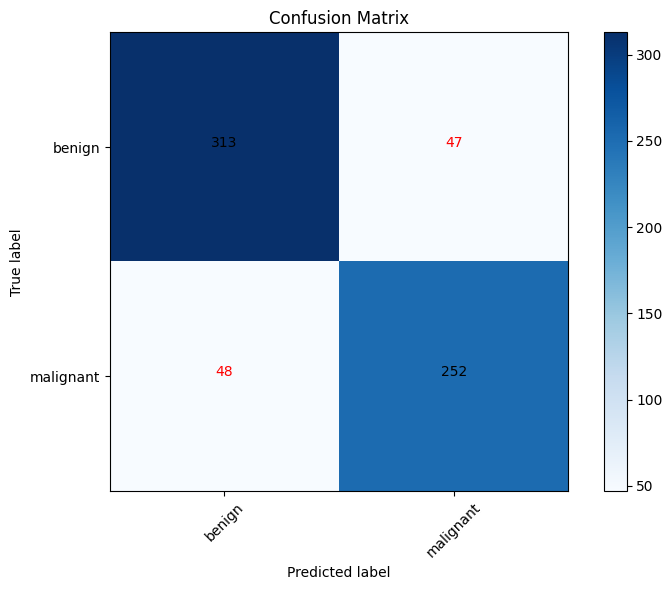

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    """
    This function prints and plots the confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     horizontalalignment="center",
                     color="black" if cm[i, j] > thresh else "red")  # Set text color to black for values above threshold

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

# Generate predictions
Y_pred_mobilenet = model_mobilenet.predict(test_generator)
y_pred_mobilenet = np.argmax(Y_pred_mobilenet, axis=1)
classes = list(test_generator.class_indices.keys())

# Plot confusion matrix
plot_confusion_matrix(test_generator.classes, y_pred_mobilenet, classes)

# Generate classification report
print(classification_report(test_generator.classes, y_pred_mobilenet, target_names=classes))

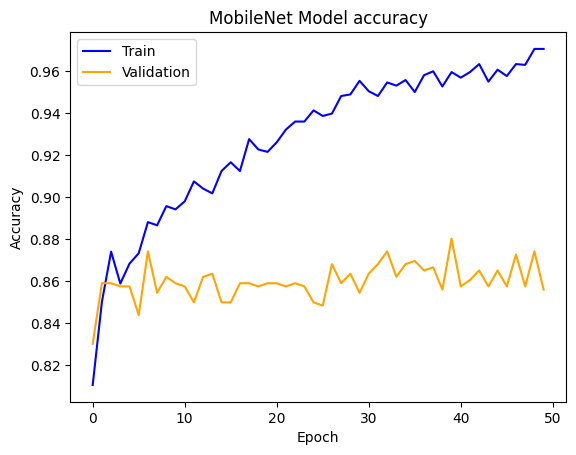

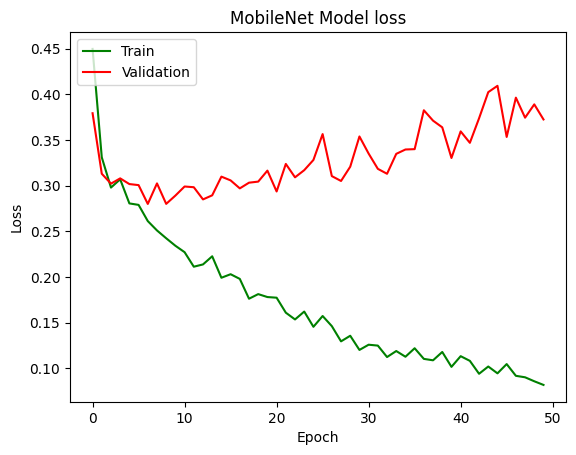

In [43]:
# Plot training & validation accuracy values with different colors
plt.plot(history_mobilenet.history['accuracy'], color='blue')
plt.plot(history_mobilenet.history['val_accuracy'], color='orange')
plt.title('MobileNet Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values with different colors
plt.plot(history_mobilenet.history['loss'], color='green')
plt.plot(history_mobilenet.history['val_loss'], color='red')
plt.title('MobileNet Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
              precision    recall  f1-score   support

      benign       0.89      0.87      0.88       360
   malignant       0.85      0.87      0.86       300

    accuracy                           0.87       660
   macro avg       0.87      0.87      0.87       660
weighted avg       0.87      0.87      0.87       660



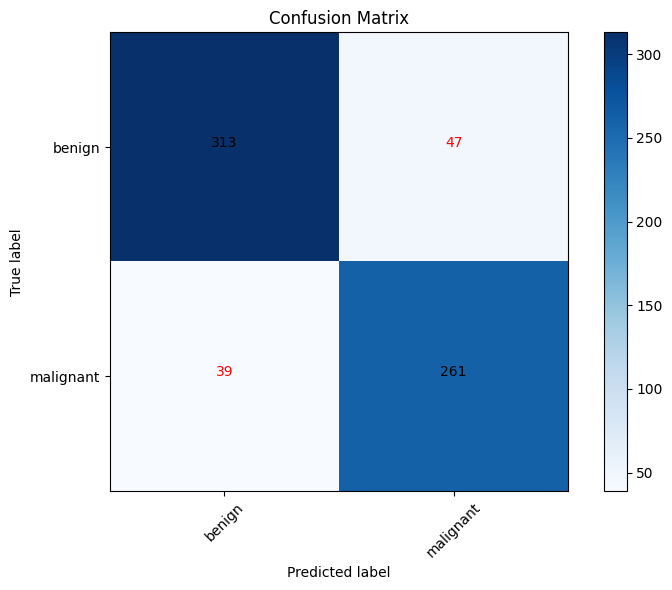

In [44]:
# Generate predictions
Y_pred_cnn = model_cnn.predict(test_generator)
y_pred_cnn = np.argmax(Y_pred_cnn, axis=1)
classes = list(test_generator.class_indices.keys())

# Plot confusion matrix
plot_confusion_matrix(test_generator.classes, y_pred_cnn, classes)

# Generate classification report
print(classification_report(test_generator.classes, y_pred_cnn, target_names=classes))

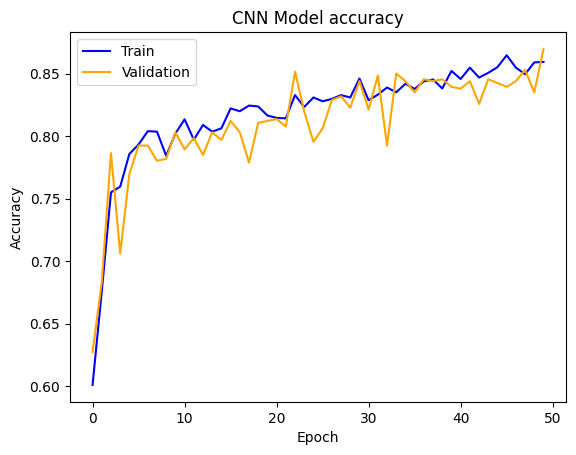

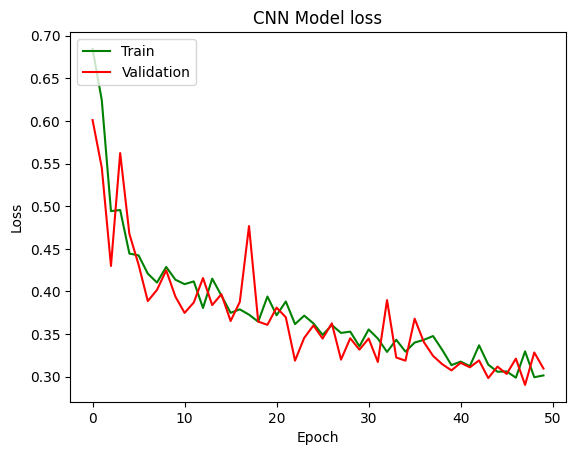

In [45]:
# Plot training & validation accuracy values with different colors
plt.plot(history_cnn.history['accuracy'], color='blue')
plt.plot(history_cnn.history['val_accuracy'], color='orange')
plt.title('CNN Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values with different colors
plt.plot(history_cnn.history['loss'], color='green')
plt.plot(history_cnn.history['val_loss'], color='red')
plt.title('CNN Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()